## Refinement based on pure reweighting
to see the advantages of on-the-fly refinement

In [1]:
import os, pickle, copy
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append('../')

from simpleMD import SimpleMD, generate_chain
# if not is_run, SimpleMD is only required to load pickles

from my_tools import compute_SAXS

In [3]:
from MDRefine import load_data, minimizer

### 0. read (or run) prior and ground truth

In [4]:
is_run = False
cell = (100., 100., 100.)

In [5]:
if is_run:
    positions = generate_chain(10, 1.)
    keys_prior = {
        'temperature' : 0.722,
        'tstep' : 0.001,
        'friction' : 1.0,
        'forcecutoff' : 2.5,
        'k_fene' : 30.0,
        'maxbond' : 1.5,
        'q_SAXS' : [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        'listcutoff' : 3.0,
        'nstep' : int(1e5),
        'nconfig' : 100,
        'nstat' : 100,
        'nequilib' : 10000,
        # pass the crystal lattice generated above
        'cell' : cell,
        'positions' : positions
        }
    
    print('run MD simulation with prior knowledge')
    smd_prior = SimpleMD(**keys_prior)
    smd_prior.run()

    print('run MD simulation for ground truth (to get experimental values)')
    keys_ref = copy.deepcopy(keys_prior)
    keys_ref.update({'k_angle' : 5.0})

    smd_reference = SimpleMD(**keys_ref)
    smd_reference.run()



In [6]:
if not is_run:
    with open("../data/prior_long.pickle", "rb") as file:
        smd_prior = pickle.load(file)
    with open("../data/test_long.pickle", "rb") as file:
        smd_reference = pickle.load(file)

In [7]:
vars(smd_prior).keys()

dict_keys(['iv', 'iy', 'iset', 'gset', 'write_positions_first', 'write_statistics_first', 'write_statistics_last_time_reopened', 'write_statistics_fp', 'temperature', 'maxneighbors', 'tstep', 'friction', 'forcecutoff', 'k_fene', 'maxbond', 'k_angle', 'l_rgyr2', 'exp_rgyr2', 'k_rgyr2', 'tau_rgyr2', 'alpha_rgyr2', 'sigma_rgyr2', 'q_SAXS', 'l_SAXS', 'a_SAXS', 'b_SAXS', 'c_SAXS', 'exp_SAXS', 'k_SAXS', 'tau_SAXS', 'alpha', 'beta', 'gamma', 'sigma_SAXS', 'k_fm', 'tau_fm', 'eta_ff0', 'tau_ff', 'listcutoff', 'nstep', 'nconfig', 'nstat', 'nequilib', 'nonthefly', 'nupdate', 'idum', 'wrapatoms', 'statfile', 'trajfile', 'outputfile', 'inputfile', 'positions', 'cell', 'statfile_f', 'statistics', 'lambda_otf', 'SAXS_otf', 'fm_otf', 'trajectory', 'SAXS', 'grad_lambda', 'angle', 'output'])

In [8]:
print(len([smd_prior.trajectory[i][1] for i in range(len(smd_prior.trajectory))]))
print(len([smd_reference.trajectory[i][1] for i in range(len(smd_reference.trajectory))]))


100000
100000


#### draw the polymer
not working

In [9]:
import MDAnalysis as mda
import py3Dmol

In [10]:
traj = np.array([smd_reference.trajectory[i][1] for i in range(len(smd_reference.trajectory))])

traj.shape

(100000, 10, 3)

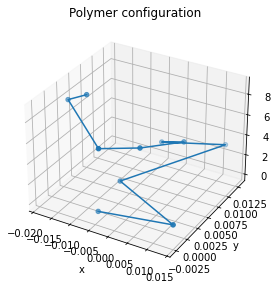

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter for monomers
i = 0  # frame index
ax.scatter(traj[i, :, 0], traj[i, :, 1], traj[i, :, 2], s=20)

# Optional: plot connectivity assuming atoms are ordered along the chain
ax.plot(traj[i, :, 0], traj[i, :, 1], traj[i, :, 2])

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Polymer configuration")

plt.tight_layout()
plt.show()

In [12]:
n_frames, n_atoms, _ = traj.shape
u = mda.Universe.empty(n_atoms, trajectory=True)

u.atoms.positions = traj[0]

with mda.coordinates.XTC.XTCWriter('traj.xtc', n_atoms) as w:
    for frame in traj:
        u.atoms.positions = frame
        w.write(u)

### 1. prepare data 
from `SimpleMD` outputs (in `data` directory) to `MDRefine` (new directory `polymer`)

do it just once (the first time you run a new trajectory)

#### `forward_qs`
from `smd_prior`

quantities required to compute the observables by evaluation of the `forward_model_fun` function
- in this case, SAXS values for each frame of the trajectory, since the correction to the forward model is a linear combination of them (for each frame)

In [13]:
traj = np.array([smd_prior.trajectory[i][1] for i in range(len(smd_prior.trajectory))])

print('shape of traj: ', traj.shape)

shape of traj:  (100000, 10, 3)


In [14]:
smd_prior.angle[5].shape

(100000,)

they have different number of frames (angle is saved every `nstat` iterations, while the trajectory every `nconfig`)

In [15]:
saxs = []

for i in range(len(traj)):
    saxs.append(compute_SAXS(traj[i], cell, smd_prior.q_SAXS))

saxs = np.array(saxs)

In [16]:
saxs.shape

(100000, 10)

In [17]:
!mkdir ../data_MDRefine
!mkdir ../data_MDRefine/polymer
!mkdir ../data_MDRefine/polymer/forward_qs

# if not 'saxs.npy' in os.listdir('../data_MDRefine/polymer/forward_qs'):
np.save('../data_MDRefine/polymer/forward_qs/saxs_long.npy', saxs)

mkdir: impossibile creare la directory "../data_MDRefine": File già esistente
mkdir: impossibile creare la directory "../data_MDRefine/polymer": File già esistente
mkdir: impossibile creare la directory "../data_MDRefine/polymer/forward_qs": File già esistente


In [18]:
lines = ["A,1", "B,0"]

with open("../data_MDRefine/original_fm_coeffs", "w") as f:
    for line in lines:
        f.write(line + "\n")

#### experimental values
from `smd_reference`

from a logical point of view, `exp_saxs` should be exactly given by `smd_reference.SAXS` I would say, without linear combination that should be added to the prior...

In [19]:
exp_saxs = 1.5*smd_reference.SAXS + 2.0
sigma_saxs = 1.0*np.ones(len(exp_saxs))

exp_vals = np.vstack((exp_saxs, sigma_saxs)).T

!mkdir ../data_MDRefine/polymer/g_exp
np.save('../data_MDRefine/polymer/g_exp/saxs_long.npy', exp_vals)

mkdir: impossibile creare la directory "../data_MDRefine/polymer/g_exp": File già esistente


In [20]:
!mkdir ../data_MDRefine/polymer/names
np.save('../data_MDRefine/polymer/names/saxs.npy', np.array(smd_reference.q_SAXS).T)

mkdir: impossibile creare la directory "../data_MDRefine/polymer/names": File già esistente


In [21]:
assert (smd_reference.q_SAXS == smd_prior.q_SAXS), 'error: mismatch on q_SAXS'

### 2. load data

In [22]:
infos = {'global': {
    'path_directory': '../data_MDRefine',
    'system_names': ['polymer_longtime'],  # 'polymer' or 'polymer_longtime' for longer MD simulation
    'g_exp': ['saxs'],
    'forward_qs': ['saxs'],
    'forward_coeffs': 'original_fm_coeffs'  # np.array([1., 0.])
}}

In [23]:
def forward_model_fun(fm_coeffs, forward_qs):
    forward_qs_out = {'saxs': fm_coeffs[0]*forward_qs['saxs'] + fm_coeffs[1]}
    return forward_qs_out

infos['global']['forward_model'] = forward_model_fun

In [24]:
data = load_data(infos)

loading data from directory...
loading  polymer_longtime
done


In [25]:
if list(data.mol.keys()) == ['polymer_longtime']:
    data.mol['polymer'] = data.mol['polymer_longtime']
    del data.mol['polymer_longtime']
    data.properties.system_names = ['polymer']

In [26]:
vars(data.mol['polymer']).keys()

dict_keys(['temperature', 'gexp', 'names', 'ref', 'forward_model', 'forward_qs', 'weights', 'g', 'n_experiments', 'n_frames'])

In [27]:
data.mol['polymer'].weights.shape

(100000,)

try with different regularizations for the coefficients of the forward model

In [28]:
def forward_model_regularization(coeffs, coeffs0):
    # L2 regularization
    regularization = (coeffs[0] - coeffs0[0])**2 + (coeffs[1] - coeffs0[1])**2
    
    # regularization used in the thesis
    # regularization = jnp.log(coeffs[0])
    return regularization

regularization = {'forward_model_reg' : forward_model_regularization}

### 3. minimize the loss function
purely based on reweighting initial trajectory

In [29]:
result = minimizer(data, regularization=regularization, alpha=1, gamma=1, if_print_biblio=False)

In [30]:
vars(result)

{'loss': Array(6.36409236, dtype=float64),
 'pars': array([ 1.55194496, -0.18659974]),
 'mini':   message: Optimization terminated successfully.
   success: True
    status: 0
       fun: 6.364092365705474
         x: [ 1.552e+00 -1.866e-01]
       nit: 9
       jac: [-4.986e-04 -2.661e-05]
  hess_inv: [[ 5.441e-04 -7.336e-03]
             [-7.336e-03  4.335e-01]]
      nfev: 14
      njev: 14,
 'min_lambdas': {'polymer': {'saxs': Array([ 0.10283001, -0.01607013, -0.14201664, -0.20525135, -0.16798781,
          -0.0400843 ,  0.12291954,  0.24797468,  0.27691082,  0.1940325 ],      dtype=float64)}},
 'minis': {'polymer':   message: Optimization terminated successfully.
    success: True
     status: 0
        fun: -6.024629694864511
          x: [ 5.982e-03 -3.631e-03 -6.884e-02 -1.658e-01 -1.957e-01
              -6.122e-02  2.297e-01  5.377e-01  6.670e-01  5.003e-01]
        nit: 0
        jac: [ 9.205e-04  2.796e-04 -3.543e-04  9.131e-05 -2.127e-04
              -4.697e-05  1.040e-04

In [31]:
print(result.mini.hess_inv)

eigvals = np.linalg.eigvals(result.mini.hess_inv)

print('\neigenvalues of the Hessian: ', eigvals)
print('one is almost zero, so there is a flat direction')

[[ 0.00054408 -0.00733586]
 [-0.00733586  0.43353023]]

eigenvalues of the Hessian:  [4.19830861e-04 4.33654486e-01]
one is almost zero, so there is a flat direction


In [32]:
vars(result).keys()

dict_keys(['loss', 'pars', 'mini', 'min_lambdas', 'minis', 'intermediates', 'time', 'reg_fm', 'D_KL_alpha', 'abs_difference', 'av_g', 'chi2', 'logZ_new', 'weights_new'])

In [33]:
result.min_lambdas

{'polymer': {'saxs': Array([ 0.10283001, -0.01607013, -0.14201664, -0.20525135, -0.16798781,
         -0.0400843 ,  0.12291954,  0.24797468,  0.27691082,  0.1940325 ],      dtype=float64)}}

In [34]:
result.intermediates.lambdas.shape

(14, 10)

In [35]:
result.intermediates.lambdas[-1]

Array([ 0.00597754, -0.00363397, -0.06883354, -0.16577078, -0.19567963,
       -0.06121507,  0.22971457,  0.53767679,  0.66701915,  0.50030068],      dtype=float64)

In [36]:
result.min_lambdas

{'polymer': {'saxs': Array([ 0.10283001, -0.01607013, -0.14201664, -0.20525135, -0.16798781,
         -0.0400843 ,  0.12291954,  0.24797468,  0.27691082,  0.1940325 ],      dtype=float64)}}

In [37]:
result.intermediates.loss

Array([703.99629292, 433.59754297, 124.44062865, 148.37088007,
        24.76714964,  10.82476745,   6.36531193,   6.36409677,
         6.36409239,   6.36409237,   6.36409236,   6.36409239,
         6.36409237,   6.36409237], dtype=float64)

why `result.intermediates.lambdas[-1]` is different from `result.lambdas_min`??

`result.lambdas_min` is de-normalized

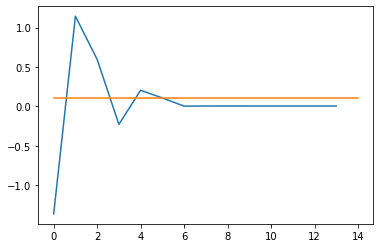

In [38]:
plt.plot(result.intermediates.lambdas[:, 0])

my_val = result.min_lambdas['polymer']['saxs'][0]

plt.plot([0, len(result.intermediates.lambdas)], my_val*np.ones(2))

In [39]:
vars(result.intermediates).keys()

dict_keys(['loss', 'pars', 'lambdas', 'minis'])

`result.intermediates.lambdas` comes from normalized observables, so to compare with on-the-fly refinement you have to denormalize them

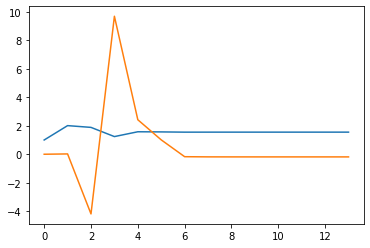

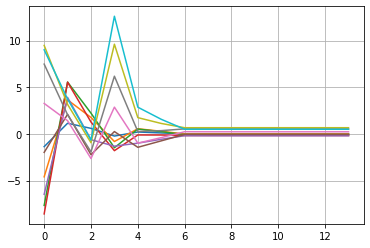

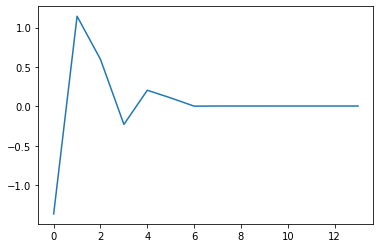

In [40]:
plt.plot(result.intermediates.pars)  # , '.')

plt.figure()
plt.plot(result.intermediates.lambdas)
plt.grid()

plt.figure()
plt.plot(result.intermediates.lambdas[:, 0])

In [41]:
new_weights = result.weights_new['polymer']

print(len(new_weights), len(smd_prior.angle[5]))

100000 100000


In [42]:
np.array([smd_prior.trajectory[i][1] for i in range(len(smd_prior.trajectory))]).shape

(100000, 10, 3)

5.877430533842276


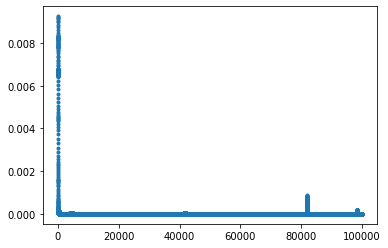

In [43]:
plt.plot(new_weights, '.')

p0 = 1/len(new_weights)
dkl = np.sum(new_weights*np.log(new_weights/p0))

print(dkl)

- checked with `shuffle`, it appears that only first frames are modified but it is just by chance

In [44]:
plt.rcParams.update({'font.size' : 19, 'lines.markersize': 7, 'lines.linewidth': 2})

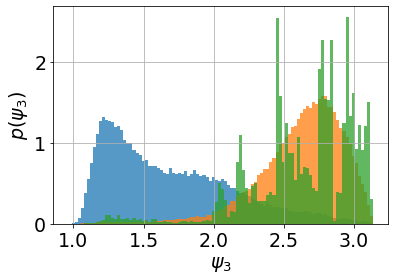

In [45]:
my_hist = {}

plt.figure(figsize=(6, 4))

out = plt.hist(smd_prior.angle[3], bins=100, density=True, alpha=0.75, label='Prior')
my_hist['prior'] = out[0]
bins = out[1]  # only in this way you can compare distributions by computing the D_KL

my_hist['reference'] = plt.hist(smd_reference.angle[3], bins=bins, density=True, alpha=0.75, label='Reference')[0]
my_hist['reweighted'] = plt.hist(smd_prior.angle[3], weights=new_weights, bins=bins, density=True, alpha=0.75, label='Posterior')[0]

for k in my_hist.values():
    k /= np.sum(k)

plt.xlabel(r'$\psi_3$')
plt.ylabel(r'$p(\psi_3)$')

# plt.yscale('symlog')

plt.grid()
# plt.savefig('../images/reweight_angular_distrib_l2reg.pdf', format='pdf', bbox_inches='tight')

# plt.legend()

In [46]:
from my_tools import compute_dkl

In [47]:
dkl1 = compute_dkl(my_hist['reweighted'], my_hist['prior'])

dkl2 = compute_dkl(my_hist['reference'], my_hist['prior'])

print(dkl1, dkl2)

2.0739609667563204 1.8645365856538847


In [48]:
print('new coefficients of the forward model: ', result.pars)

new coefficients of the forward model:  [ 1.55194496 -0.18659974]


In [49]:
result.reg_fm

0.33946270557747915

In [50]:
out_saxs = forward_model_fun(result.pars, data.mol['polymer'].forward_qs)['saxs']
out_saxs_av = np.mean(out_saxs, axis=0)
out_saxs_av2 = np.average(out_saxs, axis=0, weights=new_weights)


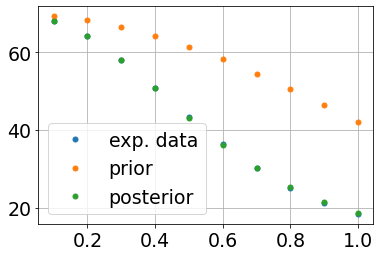

In [51]:
plt.rcParams['lines.markersize'] = 10

plt.plot(smd_prior.q_SAXS, data.mol['polymer'].gexp['saxs'][:, 0], '.', label='exp. data')
plt.plot(smd_prior.q_SAXS, out_saxs_av, '.', label='prior')
plt.plot(smd_prior.q_SAXS, out_saxs_av2, '.', label='posterior')
plt.legend()
plt.grid()

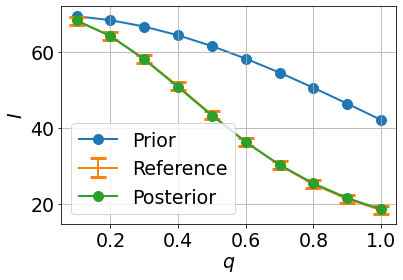

In [52]:
plt.figure(figsize=(6, 4))
plt.plot(smd_prior.q_SAXS, out_saxs_av, '-o', label='Prior', zorder=1)
# plt.plot(smd_posterior.q_SAXS, smd_posterior.exp_SAXS, '-o', label='Reference', linewidth=3)
plt.errorbar(smd_prior.q_SAXS, data.mol['polymer'].gexp['saxs'][:, 0], data.mol['polymer'].gexp['saxs'][:, 1], label='Reference', capsize=8, capthick=3, zorder=2)
plt.plot(smd_prior.q_SAXS, out_saxs_av2, '-o', label='Posterior', zorder=3)

plt.xlabel(r'$q$')
plt.ylabel(r'$I$')#\,(q)$')
plt.grid()

handles, labels = plt.gca().get_legend_handles_labels()
handles = [handles[0], handles[2], handles[1]]
labels = [labels[0], labels[2], labels[1]]
plt.legend(handles, labels, loc='lower left')

# plt.savefig('../images/chap2_SAXSlfinal2.pdf', format='pdf', bbox_inches='tight')

# plt.show()

### shuffle?
what happens?

In [53]:
arr = np.arange(len(data.mol['polymer'].weights))

np.random.shuffle(arr)

arr

array([65309, 10527, 62555, ..., 23245, 58047, 20868])

In [54]:
data.mol['polymer'].forward_qs['saxs'] = data.mol['polymer'].forward_qs['saxs'][arr]
data.mol['polymer'].g['saxs'] = data.mol['polymer'].g['saxs'][arr]
data.mol['polymer'].weights = data.mol['polymer'].weights[arr]

I get the same result by `minimizer`, as it must be
(I was quite surprised by the plot of the new weights, since it seemed that only initial weights were modified)